# 00 - Dataset Exploration

This notebook explores the **ACA Butterflies** dataset and documents the split strategy.

**Split strategy:**
- The Kaggle competition provides a separate unlabelled `test/` folder for the final submission.
- The labelled `train.csv` is split into **Train (80%) / Validation (20%)** only.
- Model comparison is done on the validation set; final scores come from the Kaggle leaderboard.

## Sections
1. Setup & Imports
2. Dataset Download (Kaggle)
3. Data Collection & Structure
4. Cleaning & Quality Assessment
5. Class Distribution
6. Sanity Check (visual samples)
7. Train / Validation Split
8. Label Encoding
9. Image Statistics

## 1. Setup & Imports

In [1]:
import os, sys, json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.utils.data as data
import torchvision.transforms as transforms

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():            device = torch.device('cuda')
elif torch.backends.mps.is_available(): device = torch.device('mps')
else:                                    device = torch.device('cpu')
print('Device:', device)

NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
for c in [os.path.join(NOTEBOOK_DIR,'../src'), os.path.join(NOTEBOOK_DIR,'src'),
          '/Applications/Universidade/4ano_2semestre/ACA/projeto2/aml-butterfly-generative-augmentation/src']:
    c = os.path.abspath(c)
    if os.path.isdir(c) and c not in sys.path:
        sys.path.append(c); break

from dataset import ButterflyDataset
from utils import get_splits, get_class_mapping, GLOBAL_SEED
print('Modules imported!')

Device: mps
Modules imported!


## 2. Dataset Download (Kaggle)

In [2]:
import kagglehub

path = kagglehub.competition_download('aca-tp-2')

train_dir = os.path.join(path, 'train')
test_dir  = os.path.join(path, 'test')   # unlabelled — for Kaggle submission
train_csv = os.path.join(path, 'train.csv')

print('Dataset path:', path)
print('Contents    :', os.listdir(path))
print('Test images :', len(os.listdir(test_dir)), '(unlabelled — submission only)')

Dataset path: /Users/matildecarvalho/.cache/kagglehub/competitions/aca-tp-2
Contents    : ['test', 'train', 'train.csv']
Test images : 1300 (unlabelled — submission only)


## 3. Data Collection & Structure

In [3]:
df = pd.read_csv(train_csv)

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Number of classes:', df['label'].nunique())
print('Number of images  :', len(df))
display(df.head())

Shape: (5199, 2)
Columns: ['filename', 'label']
Number of classes: 75
Number of images  : 5199


,filename,label
0,Image_0.jpg,CLOUDED SULPHUR
1,Image_1.jpg,GREAT JAY
2,Image_2.jpg,BLACK HAIRSTREAK
3,Image_3.jpg,INDRA SWALLOW
4,Image_4.jpg,VICEROY


## 4. Cleaning & Quality Assessment

In [4]:
df['filepath'] = df['filename'].apply(lambda x: os.path.join(train_dir, x))
df['exists']   = df['filepath'].apply(os.path.exists)

print('Images found  :', df['exists'].sum())
print('Images missing:', (~df['exists']).sum())
print('Duplicate filenames:', df['filename'].duplicated().sum())
print('\nNull values:\n', df.isnull().sum())

ok = df['exists'].all() and df['filename'].duplicated().sum() == 0
print('\nConclusion: Dataset consistent.' if ok else '\nWARNING: Issues found!')

Images found  : 5199
Images missing: 0
Duplicate filenames: 0

Null values:
 filename    0
label       0
filepath    0
exists      0
dtype: int64

Conclusion: Dataset consistent.


## 5. Class Distribution

count     75.00000
mean      69.32000
std        7.38362
min       57.00000
25%       65.00000
50%       69.00000
75%       74.00000
max      105.00000
Name: count, dtype: float64


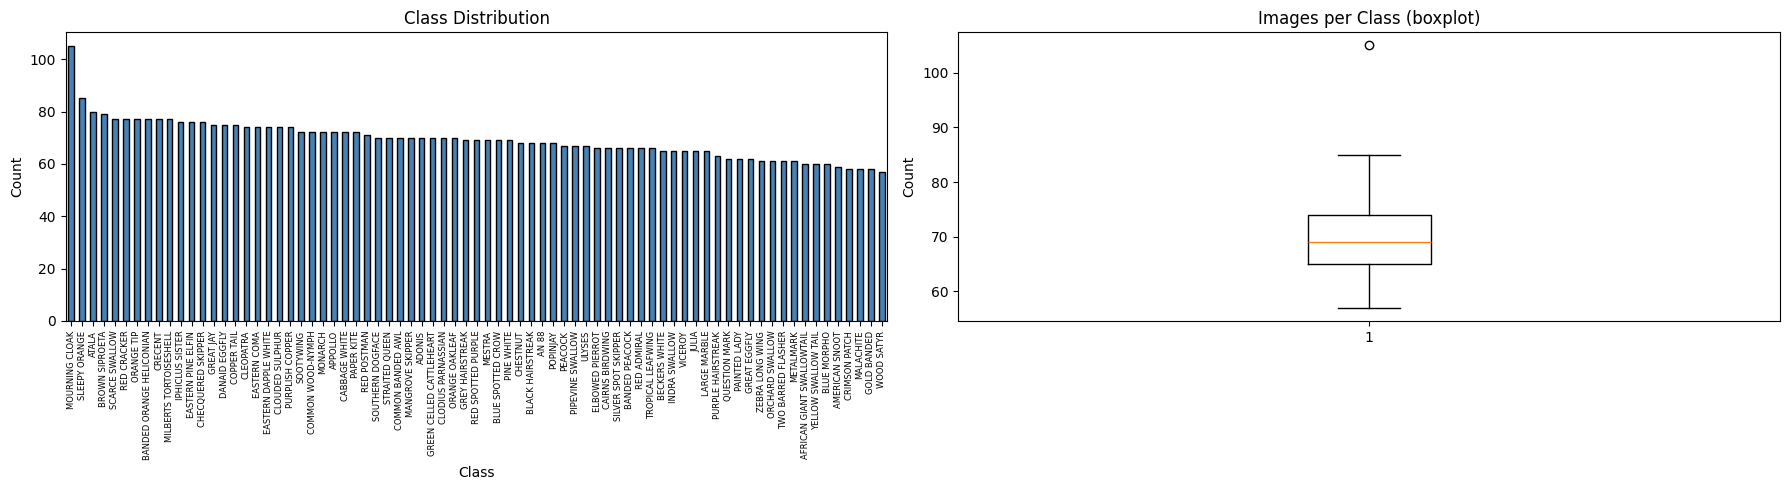

Coefficient of variation: 0.11
Balanced.


In [5]:
class_counts = df['label'].value_counts()
print(class_counts.describe())

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
class_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', labelsize=6, rotation=90)

axes[1].boxplot(class_counts.values)
axes[1].set_title('Images per Class (boxplot)')
axes[1].set_ylabel('Count')

plt.tight_layout(); plt.show()

cv = class_counts.std() / class_counts.mean()
print(f'Coefficient of variation: {cv:.2f}')
print('Balanced.' if cv < 0.2 else 'Imbalanced — generative augmentation may help!')

## 6. Sanity Check — Visual Samples

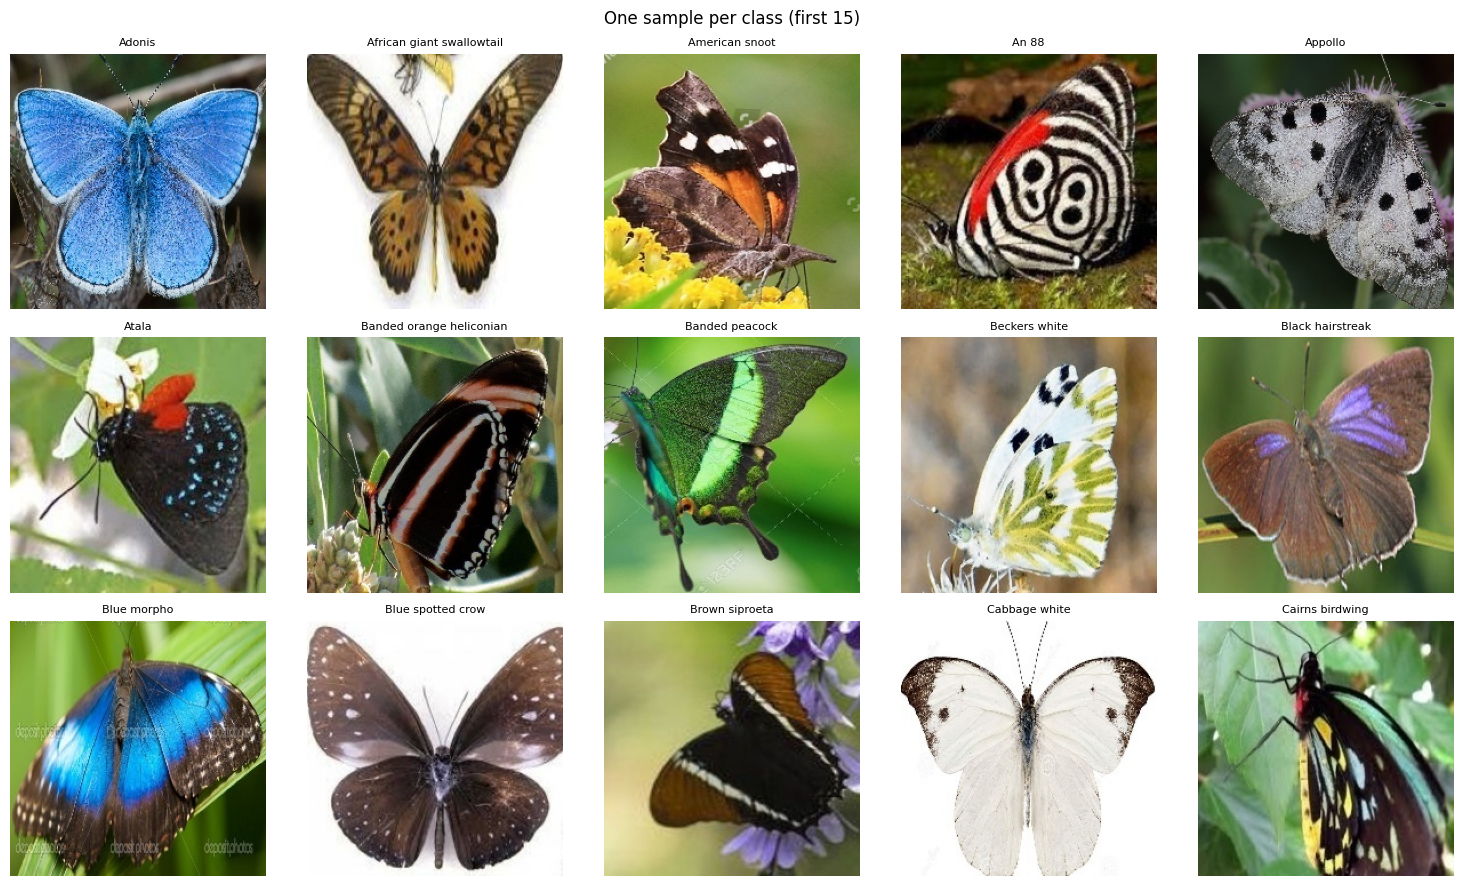

In [6]:
classes_sample = sorted(df['label'].unique())[:15]
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i, cls in enumerate(classes_sample):
    row = df[df['label'] == cls].sample(1, random_state=SEED).iloc[0]
    img = Image.open(row['filepath']).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(cls.capitalize(), fontsize=8)
    axes[i].axis('off')

plt.suptitle('One sample per class (first 15)', fontsize=12)
plt.tight_layout(); plt.show()

## 7. Train / Validation Split

The Kaggle competition provides a separate unlabelled `test/` folder for submission.
Therefore the labelled `train.csv` is split into:

| Split | Size | Purpose |
|---|---|---|
| **Train** | 80% | Update model weights |
| **Validation** | 20% | Monitor training, compare models |

Calling `get_splits(df, seed=GLOBAL_SEED)` in every notebook always produces the same subsets.

In [7]:
df_clean = df[['filename', 'label']].copy()

train_df, val_df = get_splits(df_clean, seed=GLOBAL_SEED)

total = len(df_clean)
print(f'Total      : {total}')
print(f'Train      : {len(train_df)}  ({len(train_df)/total*100:.1f}%)')
print(f'Validation : {len(val_df)}   ({len(val_df)/total*100:.1f}%)')
print(f'Classes in train : {train_df["label"].nunique()}')
print(f'Classes in val   : {val_df["label"].nunique()}')

Total      : 5199
Train      : 4159  (80.0%)
Validation : 1040   (20.0%)
Classes in train : 75
Classes in val   : 75


## 8. Label Encoding

In [8]:
class_to_idx, idx_to_class, classes = get_class_mapping(df_clean)
NUM_CLASSES = len(classes)

print(f'Number of classes: {NUM_CLASSES}')
print('First 5 mappings:')
for k, v in list(class_to_idx.items())[:5]:
    print(f'  {k!r} -> {v}')

Number of classes: 75
First 5 mappings:
  'ADONIS' -> 0
  'AFRICAN GIANT SWALLOWTAIL' -> 1
  'AMERICAN SNOOT' -> 2
  'AN 88' -> 3
  'APPOLLO' -> 4


## 9. Image Statistics

Pixel mean and std computed on the **training set only** (avoids leakage from validation).
Update the values in `src/transforms.py` after running this cell.

In [9]:
IMAGE_SIZE = 64

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

dataset = ButterflyDataset(df=train_df, img_dir=train_dir, transform=transform)
loader  = data.DataLoader(dataset, batch_size=64, shuffle=False, num_workers=0)

mean = torch.zeros(3)
std  = torch.zeros(3)
n    = 0

for imgs, _ in loader:
    b    = imgs.size(0)
    flat = imgs.view(b, 3, -1)
    mean += flat.mean(2).sum(0)
    std  += flat.std(2).sum(0)
    n    += b

mean /= n
std  /= n

print(f'Mean (R,G,B): {mean.tolist()}')
print(f'Std  (R,G,B): {std.tolist()}')
print('\nCopy these values into src/transforms.py (BUTTERFLY_MEAN / BUTTERFLY_STD).')

Mean (R,G,B): [0.47978127002716064, 0.46559423208236694, 0.33797529339790344]
Std  (R,G,B): [0.2159816473722458, 0.21084801852703094, 0.2042972892522812]

Copy these values into src/transforms.py (BUTTERFLY_MEAN / BUTTERFLY_STD).


## Summary

| Property | Value |
|---|---|
| Labelled images | see above |
| Split | 80% train / 20% val |
| Test set | Kaggle `test/` folder (unlabelled — submit predictions) |
| Seed | `GLOBAL_SEED = 42` in `src/utils.py` |
| Image size | 64 x 64 |

**Next steps:**
- `01_baseline_training.ipynb` — train & evaluate the baseline CNN, generate submission file
- `02_autoencoder.ipynb` — train VAE for generative augmentation
- `03_gan.ipynb` — train GAN for generative augmentation